# Student Performance Indicator

## Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

## 1) Problem Statement

This project aims to understand how the student's performance (test scores) is affected by various factors such as Gender, Ethnicity, Parental Level of Education, Lunch type, and Test Preparation Course.

## 2) Data Collection

- Dataset Source: Kaggle  
- Dataset Name: Student Performance Dataset  
- The data consists of multiple attributes related to students' academic performance.

# 2.1  Impoort  data  and requirement packages

imprting numpy,pandas,matplotlib,deaborn and warings Library.


In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## import the CSV Data as pandas dataframe

In [5]:
df =pd.read_csv('data/stud.csv')

### show toop 5 records

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## shape of the dataset

In [7]:
df.shape

(1000, 8)

# 2.2 DATASET Information

1.gender: sex of students->(male/female)
2.race/ethnic:ethnicity of students ->(Group A,B,C,D,E)
3.parental lavel od education: parents final education ->(bachelor degree,some college,masters degree)
4.lunch: having lunch before test(standered or free/reduced)
5.test preparation cource: complite or not complite before test
6.math score
7.reading score
8.writing score

## 3) Data Checks to Perform

- Check Missing Values  
- Check Duplicates  
- Check Data Types  
- Check the number of unique values of each column  
- Check statistics of dataset  

### 3.1check missing value

In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### 3.2 check duplicates value


In [9]:
df.duplicated().sum()

np.int64(0)

### 3.3 check data types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the number of unique values of each column

In [11]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 Check stastic of datacet

In [12]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## insight
1. from above descripton of numerical data,all means are very close to each other - between 66 and67.05;
2. all standared devisions are also close - between 15.19;
3. While there is a minimum score 0 for math, for writing minimum is much higher =10 and for reading meyt heigher = 17

Exploratory Data Analysis involves analyzing the dataset to summarize its main characteristics, often using visual methods.

## 3.7 exploring data

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
print("Categories in 'gender' variable:  ",end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable:  ",end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:  ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:  ",end=" ")
print(df['test preparation course'].unique())


Categories in 'gender' variable:   ['female' 'male']
Categories in 'race/ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:   ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:   ['standard' 'free/reduced']
Categories in 'test preparation course' variable:   ['none' 'completed']


In [15]:
#define numerical & catagorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
catagorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

#print columns
print('we have {} numeric_features : {}'.format(len(numeric_features),numeric_features))
print('we have {} catagorical_features : {}'.format(len(catagorical_features),catagorical_features))


we have 3 numeric_features : ['math score', 'reading score', 'writing score']
we have 5 catagorical_features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [16]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


## 3.8 Adding columns for "total score" and "Average"

In [20]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score'] / 3
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [22]:
reading_full = df[df['reading score'] == 100]['average score'].count()
writing_full = df[df['writing score'] == 100]['average score'].count()
math_full = df[df['math score'] == 100]['average score'].count()

print('Number of students with full score in reading: ', reading_full)
print('Number of students with full score in writing: ', writing_full)
print('Number of students with full score in math: ', math_full)

Number of students with full score in reading:  17
Number of students with full score in writing:  14
Number of students with full score in math:  7


In [24]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total score', 'average score'],
      dtype='object')


### insights

1.From above values we get students have performs have performed the worst in math
2.best perform  is in reading

## 4. Expoloring  Data (Visualization)

### 4.1 visualize avarege score distribution to make some conclusion.

1. histogram
2. kernel Distribution Function(KDE)

## 4.1.1 histagrame &KDE

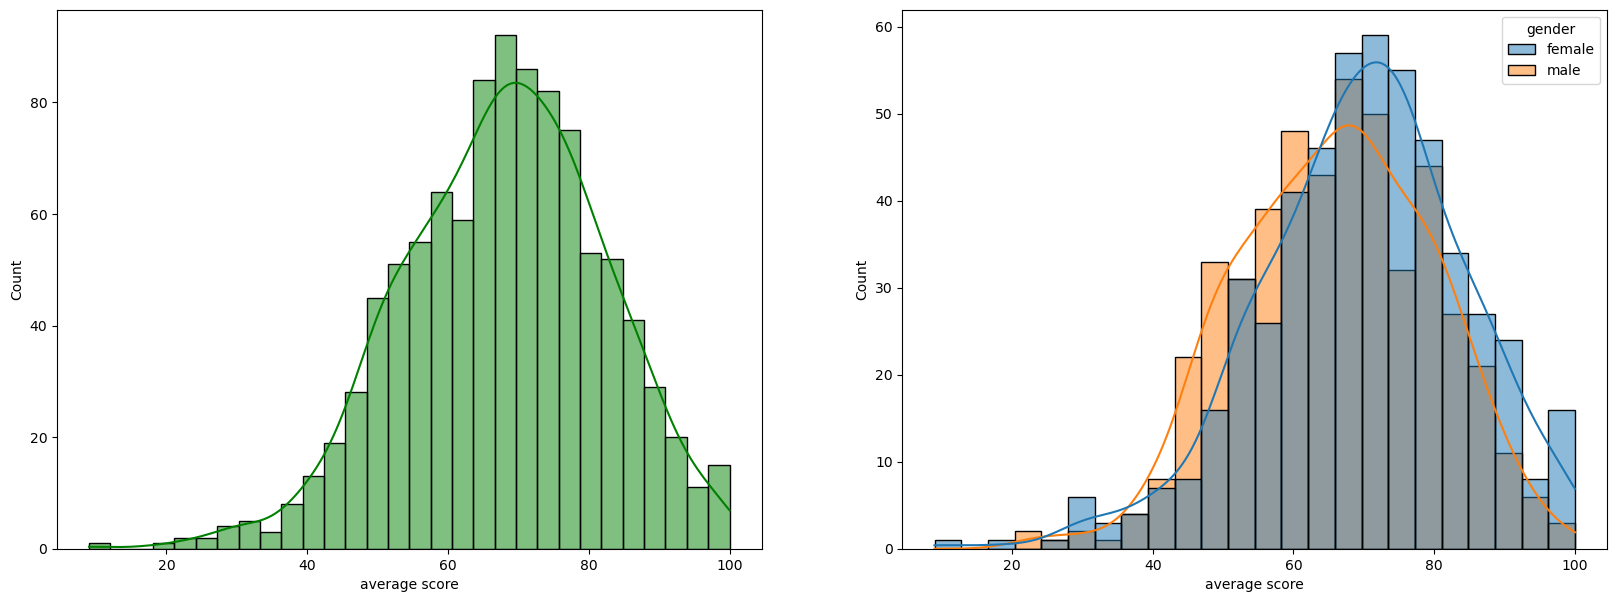

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))
plt.subplot(121)
sns.histplot(data =df, x='average score',bins =30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data =df, x='average score',kde=True, hue='gender')
plt.show()

## 6) Model Training

## 7) Choose Best Model

The best model will be selected based on evaluation metrics such as accuracy, R2 score, and error values.